# Critical Front Vehicle + Traffic Light Decision Notebook

YOLO çıktısından kritik ön-şerit aracı seçer, bbox yüksekliğinden yaklaşık mesafe hesaplar,
trafik ışığı durumu ile birleştirir ve STOP/GO kararı üretir.

In [119]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO


In [120]:
PROJECT_ROOT = Path(r"C:\Users\hdgn5\OneDrive\Masaüstü\autonomous_driving_project")
MODEL_PATH = PROJECT_ROOT / "outputs" / "models" / "bdd_yolo_v14" / "weights" / "best.pt"
IMAGE_PATH = PROJECT_ROOT / "outputs" / "prepared_data" / "bdd_yolo" / "images" / "val" / "b60f1db0-b9889ec7.jpg"

print("MODEL_PATH:", MODEL_PATH)
print("IMAGE_PATH:", IMAGE_PATH)

MODEL_PATH: C:\Users\hdgn5\OneDrive\Masaüstü\autonomous_driving_project\outputs\models\bdd_yolo_v14\weights\best.pt
IMAGE_PATH: C:\Users\hdgn5\OneDrive\Masaüstü\autonomous_driving_project\outputs\prepared_data\bdd_yolo\images\val\b60f1db0-b9889ec7.jpg


In [121]:
def show_bgr(img, title="image", figsize=(16, 10)):
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=figsize)
    plt.imshow(img_rgb)
    plt.title(title)
    plt.axis("off")
    plt.show()


def clamp_box(box, frame_shape):
    h, w = frame_shape[:2]
    x1, y1, x2, y2 = box
    x1 = max(0, min(int(x1), w - 1))
    y1 = max(0, min(int(y1), h - 1))
    x2 = max(0, min(int(x2), w - 1))
    y2 = max(0, min(int(y2), h - 1))
    if x2 <= x1:
        x2 = min(w - 1, x1 + 1)
    if y2 <= y1:
        y2 = min(h - 1, y1 + 1)
    return x1, y1, x2, y2


def crop_from_box(frame, box):
    x1, y1, x2, y2 = clamp_box(box, frame.shape)
    crop = frame[y1:y2, x1:x2]
    if crop.size == 0:
        return None
    return crop


def box_center(box):
    x1, y1, x2, y2 = box
    return (x1 + x2) / 2.0, (y1 + y2) / 2.0


def box_width_height(box):
    x1, y1, x2, y2 = box
    return max(1, x2 - x1), max(1, y2 - y1)


def draw_box(frame, box, label, color=(0, 255, 0), thickness=2):
    x1, y1, x2, y2 = clamp_box(box, frame.shape)
    cv2.rectangle(frame, (x1, y1), (x2, y2), color, thickness)
    ((text_w, text_h), _) = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.55, 2)
    y_text = max(20, y1 - 8)
    cv2.rectangle(
        frame,
        (x1, max(0, y_text - text_h - 8)),
        (x1 + text_w + 8, y_text + 4),
        color,
        -1,
    )
    cv2.putText(
        frame,
        label,
        (x1 + 4, y_text),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.55,
        (0, 0, 0),
        2,
        cv2.LINE_AA,
    )
    return frame


In [122]:
def count_mask_pixels(hsv, lower, upper):
    mask = cv2.inRange(hsv, np.array(lower, dtype=np.uint8), np.array(upper, dtype=np.uint8))
    return int(np.count_nonzero(mask))


def detect_traffic_light_color(crop):
    if crop is None or crop.size == 0:
        return {"state": "unknown", "scores": {"red": 0, "yellow": 0, "green": 0}}

    h, w = crop.shape[:2]
    if h < 8 or w < 8:
        return {"state": "unknown", "scores": {"red": 0, "yellow": 0, "green": 0}}

    hsv = cv2.cvtColor(crop, cv2.COLOR_BGR2HSV)
    top = hsv[0:h // 3, :]
    mid = hsv[h // 3: 2 * h // 3, :]
    bot = hsv[2 * h // 3:, :]

    red_score = count_mask_pixels(top, (0, 90, 90), (10, 255, 255)) + count_mask_pixels(top, (160, 90, 90), (180, 255, 255))
    yellow_score = count_mask_pixels(mid, (15, 90, 90), (40, 255, 255))
    green_score = count_mask_pixels(bot, (40, 70, 70), (95, 255, 255))

    scores = {"red": red_score, "yellow": yellow_score, "green": green_score}
    best_state = max(scores, key=scores.get)
    best_score = scores[best_state]

    min_pixels = max(10, int((h * w) * 0.01))
    if best_score < min_pixels:
        best_state = "unknown"

    return {"state": best_state, "scores": scores}


In [123]:
def estimate_distance_from_bbox_height(box, k=1200.0):
    _, h = box_width_height(box)
    return k / float(h)


def select_main_traffic_light(detections, conf_thr=0.35):
    tls = []
    for det in detections:
        if det["class_name"] != "traffic light":
            continue
        if det["conf"] < conf_thr:
            continue
        x1, y1, x2, y2 = det["box"]
        w = x2 - x1
        h = y2 - y1
        if w < 8 or h < 12:
            continue
        tls.append(det)
    if not tls:
        return None
    return max(tls, key=lambda d: d["conf"])


def select_critical_front_car(detections, frame_shape, conf_thr=0.35):
    frame_h, frame_w = frame_shape[:2]
    lane_x_min = frame_w * 0.35
    lane_x_max = frame_w * 0.65

    candidate_cars = []
    for det in detections:
        if det["class_name"] != "car":
            continue
        if det["conf"] < conf_thr:
            continue

        box = det["box"]
        cx, cy = box_center(box)
        bw, bh = box_width_height(box)

        if bw < 20 or bh < 20:
            continue
        if not (lane_x_min <= cx <= lane_x_max):
            continue

        candidate_cars.append(det)

    if not candidate_cars:
        return None

    critical_car = max(candidate_cars, key=lambda d: box_width_height(d["box"])[1])
    return critical_car


def decision_engine_stop_go(detections, frame_shape, distance_k=1200.0):
    summary = {
        "traffic_light_state": "unknown",
        "critical_car_found": False,
        "critical_car_distance": None,
        "action": "GO",
        "reason": "default_go",
    }

    main_tl = select_main_traffic_light(detections, conf_thr=0.35)
    critical_car = select_critical_front_car(detections, frame_shape, conf_thr=0.35)

    if main_tl is not None:
        tl_state = main_tl.get("traffic_light_state", "unknown")
        summary["traffic_light_state"] = tl_state
        summary["main_tl_box"] = main_tl["box"]

    if critical_car is not None:
        dist = estimate_distance_from_bbox_height(critical_car["box"], k=distance_k)
        summary["critical_car_found"] = True
        summary["critical_car_distance"] = dist
        summary["critical_car_box"] = critical_car["box"]
        summary["critical_car_conf"] = critical_car["conf"]

    tl_state = summary["traffic_light_state"]
    car_dist = summary["critical_car_distance"]
    stop_distance = 14.0

    if tl_state == "red":
        summary["action"] = "STOP"
        summary["reason"] = "red_light"
    elif tl_state == "green":
        if car_dist is not None and car_dist < stop_distance:
            summary["action"] = "STOP"
            summary["reason"] = "front_car_too_close_on_green"
        else:
            summary["action"] = "GO"
            summary["reason"] = "green_and_clear"
    else:
        if car_dist is not None and car_dist < stop_distance:
            summary["action"] = "STOP"
            summary["reason"] = "unknown_light_but_front_car_close"
        else:
            summary["action"] = "GO"
            summary["reason"] = "unknown_light_and_clear"

    return summary


In [124]:
model = YOLO(str(MODEL_PATH))
frame = cv2.imread(str(IMAGE_PATH))
if frame is None:
    raise ValueError(f"Görsel okunamadı: {IMAGE_PATH}")

results = model.predict(source=frame, conf=0.35, iou=0.45, verbose=False)
result = results[0]

detections = []
if result.boxes is not None:
    for box in result.boxes:
        xyxy = box.xyxy[0].tolist()
        conf = float(box.conf[0].item())
        cls_id = int(box.cls[0].item())
        cls_name = result.names[cls_id]
        detections.append({
            "box": tuple(map(int, xyxy)),
            "conf": conf,
            "class_id": cls_id,
            "class_name": cls_name,
        })

print("Detection sayısı:", len(detections))
detections[:10]


Detection sayısı: 27


[{'box': (476, 359, 1010, 625),
  'conf': 0.9190707802772522,
  'class_id': 0,
  'class_name': 'car'},
 {'box': (1068, 345, 1167, 541),
  'conf': 0.8507368564605713,
  'class_id': 3,
  'class_name': 'person'},
 {'box': (105, 319, 163, 465),
  'conf': 0.8322826027870178,
  'class_id': 3,
  'class_name': 'person'},
 {'box': (412, 335, 610, 414),
  'conf': 0.8166528344154358,
  'class_id': 0,
  'class_name': 'car'},
 {'box': (346, 337, 373, 398),
  'conf': 0.8139528632164001,
  'class_id': 3,
  'class_name': 'person'},
 {'box': (177, 314, 245, 497),
  'conf': 0.8032611012458801,
  'class_id': 3,
  'class_name': 'person'},
 {'box': (1224, 330, 1280, 501),
  'conf': 0.7669780254364014,
  'class_id': 3,
  'class_name': 'person'},
 {'box': (30, 136, 72, 172),
  'conf': 0.7276467084884644,
  'class_id': 1,
  'class_name': 'traffic sign'},
 {'box': (0, 98, 35, 129),
  'conf': 0.7273238301277161,
  'class_id': 1,
  'class_name': 'traffic sign'},
 {'box': (275, 84, 392, 112),
  'conf': 0.72483092

In [125]:
for det in detections:
    if det["class_name"] == "traffic light":
        crop = crop_from_box(frame, det["box"])
        tl_info = detect_traffic_light_color(crop)
        det["traffic_light_state"] = tl_info["state"]
        det["traffic_light_scores"] = tl_info["scores"]

traffic_lights = [d for d in detections if d['class_name'] == 'traffic light']
print("Traffic light sayısı:", len(traffic_lights))
for det in traffic_lights:
    print(det["box"], det.get("traffic_light_state", "unknown"), det.get("traffic_light_scores", {}))


Traffic light sayısı: 4
(418, 93, 444, 148) red {'red': 230, 'yellow': 2, 'green': 0}
(372, 292, 391, 310) yellow {'red': 28, 'yellow': 40, 'green': 0}
(964, 222, 982, 257) red {'red': 104, 'yellow': 0, 'green': 0}
(403, 255, 420, 285) yellow {'red': 0, 'yellow': 32, 'green': 0}


In [126]:
summary = decision_engine_stop_go(detections, frame.shape, distance_k=1200.0)
summary


{'traffic_light_state': 'red',
 'critical_car_found': True,
 'critical_car_distance': 4.511278195488722,
 'action': 'STOP',
 'reason': 'red_light',
 'main_tl_box': (418, 93, 444, 148),
 'critical_car_box': (476, 359, 1010, 625),
 'critical_car_conf': 0.9190707802772522}

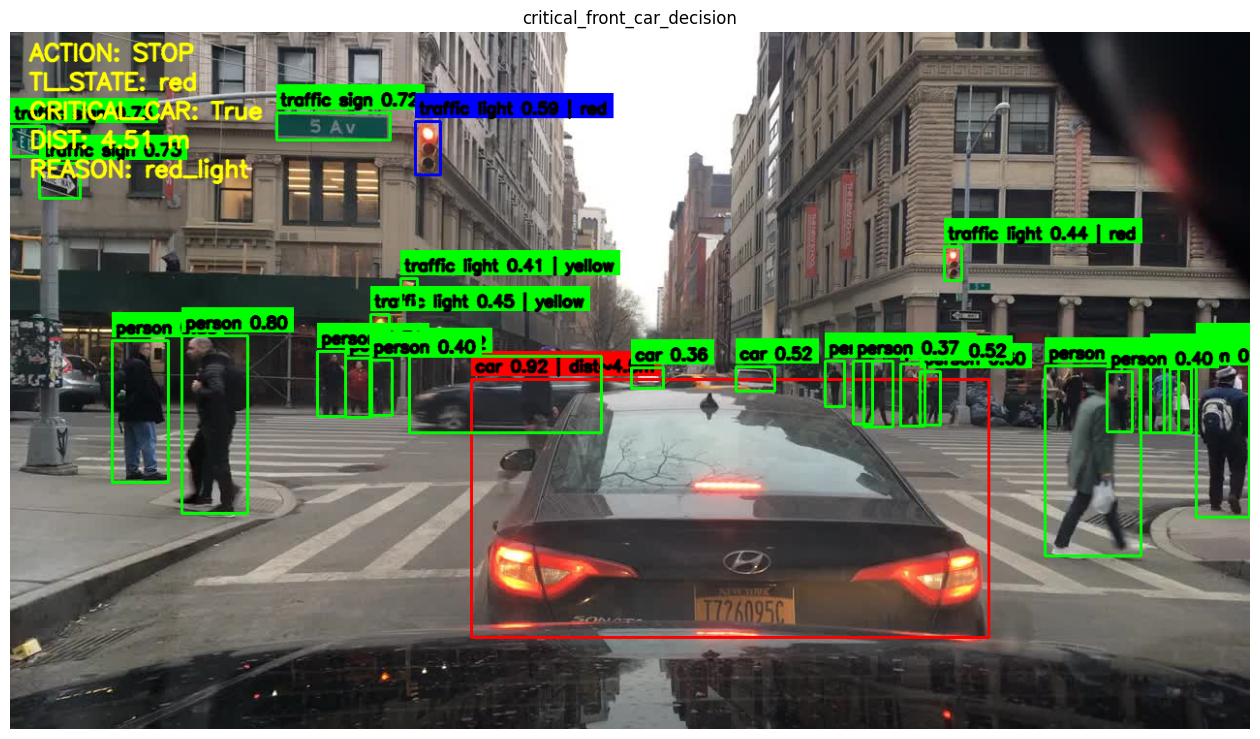

In [127]:
vis = frame.copy()
critical_box = summary.get("critical_car_box", None)
main_tl_box = summary.get("main_tl_box", None)

for det in detections:
    label = f"{det['class_name']} {det['conf']:.2f}"
    color = (0, 255, 0)

    if det["class_name"] == "traffic light":
        label += f" | {det.get('traffic_light_state', 'unknown')}"
        if main_tl_box is not None and det["box"] == main_tl_box:
            color = (255, 0, 0)

    if critical_box is not None and det["class_name"] == "car" and det["box"] == critical_box:
        dist = summary["critical_car_distance"]
        label += f" | dist~{dist:.1f}m"
        color = (0, 0, 255)

    draw_box(vis, det["box"], label, color=color)

overlay_lines = [
    f"ACTION: {summary['action']}",
    f"TL_STATE: {summary['traffic_light_state']}",
    f"CRITICAL_CAR: {summary['critical_car_found']}",
    f"DIST: {summary['critical_car_distance']:.2f} m" if summary['critical_car_distance'] is not None else "DIST: -",
    f"REASON: {summary['reason']}",
]

y = 30
for line in overlay_lines:
    cv2.putText(
        vis,
        line,
        (20, y),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0, 255, 255),
        2,
        cv2.LINE_AA,
    )
    y += 30

show_bgr(vis, title="critical_front_car_decision")


In [ ]:
OUT_PATH = PROJECT_ROOT / "outputs" / "predictions" / "critical_front_car_decision.jpg"
OUT_PATH.parent.mkdir(parents=True, exist_ok=True)
cv2.imwrite(str(OUT_PATH), vis)
print("Kaydedildi:", OUT_PATH)

Kaydedildi: C:\Users\hdgn5\OneDrive\Masaüstü\autonomous_driving_project\outputs\predictions\critical_front_car_decision.jpg
